In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("C:/data-analysis-portfolio/datasets/owid-covid-data.csv")
print(df.head())

  iso_code continent     location        date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan  2020-02-24          5.0        5.0   
1      AFG      Asia  Afghanistan  2020-02-25          5.0        0.0   
2      AFG      Asia  Afghanistan  2020-02-26          5.0        0.0   
3      AFG      Asia  Afghanistan  2020-02-27          5.0        0.0   
4      AFG      Asia  Afghanistan  2020-02-28          5.0        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           NaN         NaN                  NaN  ...   
1                 NaN           NaN         NaN                  NaN  ...   
2                 NaN           NaN         NaN                  NaN  ...   
3                 NaN           NaN         NaN                  NaN  ...   
4                 NaN           NaN         NaN                  NaN  ...   

   female_smokers  male_smokers  handwashing_facilities  \
0             NaN           NaN        

In [3]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Shape: (166326, 67)

Columns:
Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'new_tests', 'total_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vac

In [4]:
columns_needed = [
'location',
'date',
'total_cases',
'new_cases',
'total_deaths',
'new_deaths',
'total_vaccinations'
]

df = df[columns_needed]

In [5]:
print(df.isnull().sum())

location                   0
date                       0
total_cases             3033
new_cases               3193
total_deaths           20875
new_deaths             20839
total_vaccinations    121132
dtype: int64


In [6]:
df = df.fillna(0)

print("Missing values handled")

Missing values handled


In [8]:
print(df.isnull().sum())

location              0
date                  0
total_cases           0
new_cases             0
total_deaths          0
new_deaths            0
total_vaccinations    0
dtype: int64


In [9]:
df['date'] = pd.to_datetime(df['date'])

In [10]:
india = df[df['location'] == 'India']
print(india.head())

      location       date  total_cases  new_cases  total_deaths  new_deaths  \
69678    India 2020-01-30          1.0        1.0           0.0         0.0   
69679    India 2020-01-31          1.0        0.0           0.0         0.0   
69680    India 2020-02-01          1.0        0.0           0.0         0.0   
69681    India 2020-02-02          2.0        1.0           0.0         0.0   
69682    India 2020-02-03          3.0        1.0           0.0         0.0   

       total_vaccinations  
69678                 0.0  
69679                 0.0  
69680                 0.0  
69681                 0.0  
69682                 0.0  


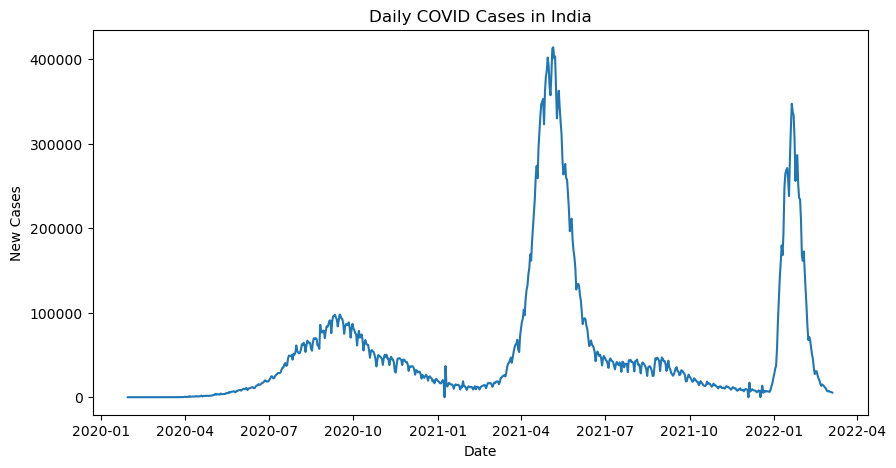

In [13]:
plt.figure(figsize=(10,5))

plt.plot(india['date'], india['new_cases'])

plt.title("Daily COVID Cases in India")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.savefig("C:/data-analysis-portfolio/visualizations/Daily COVID Cases in India")

plt.show()

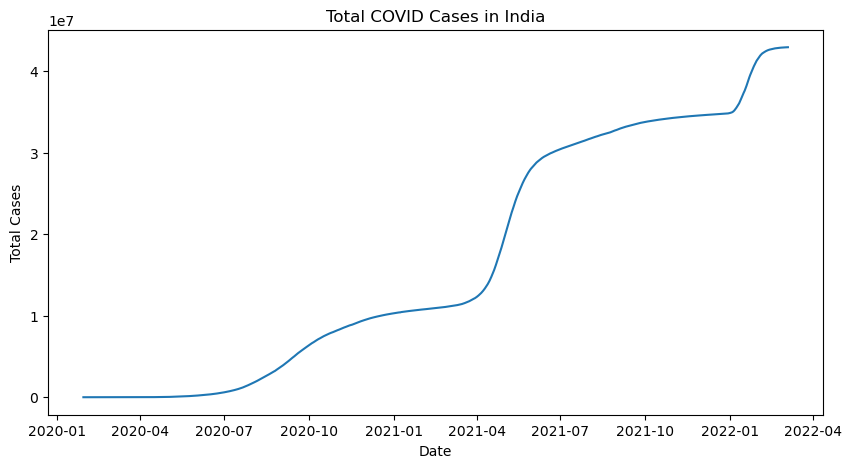

In [17]:
plt.figure(figsize=(10,5))

plt.plot(india['date'], india['total_cases'])

plt.title("Total COVID Cases in India")
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.savefig("C:/data-analysis-portfolio/visualizations/Total COVID Cases in India")

plt.show()

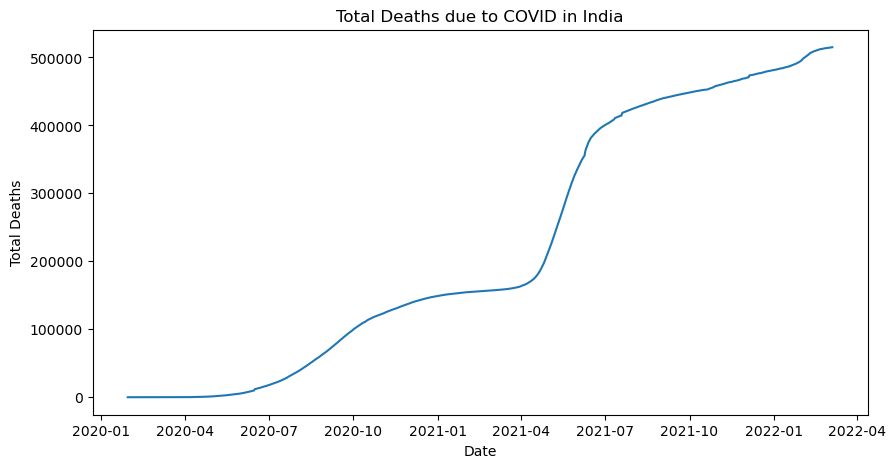

In [16]:
plt.figure(figsize=(10,5))

plt.plot(india['date'], india['total_deaths'])

plt.title("Total Deaths due to COVID in India")
plt.xlabel("Date")
plt.ylabel("Total Deaths")
plt.savefig("C:/data-analysis-portfolio/visualizations/Total Deaths due to COVID in India")
plt.show()

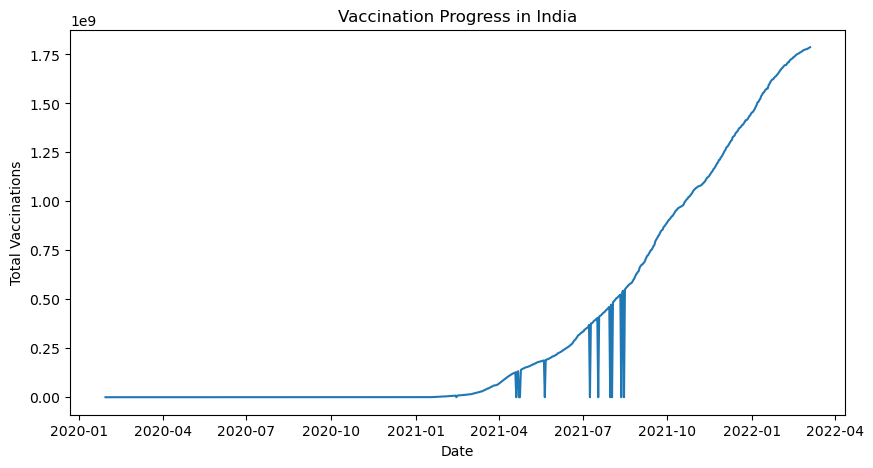

In [15]:
plt.figure(figsize=(10,5))

plt.plot(india['date'], india['total_vaccinations'])

plt.title("Vaccination Progress in India")
plt.xlabel("Date")
plt.ylabel("Total Vaccinations")
plt.savefig("C:/data-analysis-portfolio/visualizations/Vaccination Progress in India")

plt.show()

              total_cases  new_cases  total_deaths  new_deaths
total_cases      1.000000   0.222543      0.995467    0.189949
new_cases        0.222543   1.000000      0.171410    0.748538
total_deaths     0.995467   0.171410      1.000000    0.138480
new_deaths       0.189949   0.748538      0.138480    1.000000


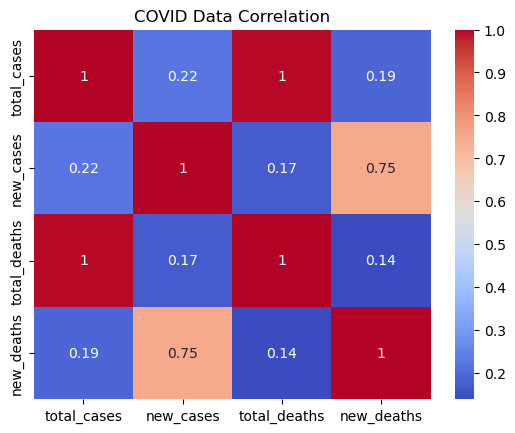

In [14]:
corr = india[['total_cases','new_cases','total_deaths','new_deaths']].corr()
print(corr)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("COVID Data Correlation")
plt.savefig("C:/data-analysis-portfolio/visualizations/COVID Data Correlation")

plt.show()